In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum().sum())

Rows: 9815
Date range: 2024-01-07 23:00:00 → 2025-02-19 21:00:00
Missing values: 0


In [19]:
df.columns.to_list()

['HourUTC',
 'HourDK',
 'PriceArea',
 'SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'target_next_hour',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [20]:
target_col = "target_next_hour"

feature_cols = [
    # calendar
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend",

    # price history
    "SpotPriceEUR",
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
    "price_rolling_mean_168h",
    "price_rolling_std_168h",

    # weather
    "temperature_2m",
    "wind_speed_10m",
    "wind_speed_100m",
    "cloud_cover",
    "shortwave_radiation",

    # energy fundamentals
    "GrossConsumptionMWh",
    "CentralPowerMWh",
    "LocalPowerMWh",
    "CommercialPowerMWh",
    "offshore_wind_mwh",
    "onshore_wind_mwh",
    "solar_mwh",
    "total_wind_mwh",
    "renewable_generation_mwh",
    "net_load_mwh",
    "ExchangeSE_MWh",
    "ExchangeGE_MWh",
    "ExchangeGreatBelt_MWh",
    "PowerToHeatMWh",
]

In [21]:
missing_cols = [col for col in feature_cols + [target_col] if col not in df.columns]
missing_cols

[]

In [22]:
split_date = "2024-11-01"

train = df[df["HourUTC"] < split_date].copy()
test = df[df["HourUTC"] >= split_date].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7153, 32)
Test: (2662, 32)


In [23]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
test["pred_xgboost"] = xgb_model.predict(X_test)

In [25]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [26]:
xgb_result = evaluate_forecast(
    test["target_next_hour"],
    test["pred_xgboost"],
    "XGBoost"
)

xgb_result

{'model': 'XGBoost', 'MAE': 14.12, 'RMSE': np.float64(39.48)}

In [27]:
baseline_results = pd.read_csv("../reports/baseline_results_DK2.csv")
baseline_results

,model,MAE,RMSE
0,Current price baseline,12.31,24.48
1,Rolling mean 24h baseline,35.92,56.36
2,Lag 24h baseline,45.13,69.95
3,Rolling mean 168h baseline,49.39,73.12
4,Lag 168h baseline,60.77,94.13


In [28]:
comparison = pd.concat(
    [baseline_results, pd.DataFrame([xgb_result])],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

comparison

,model,MAE,RMSE
0,Current price baseline,12.31,24.48
1,XGBoost,14.12,39.48
2,Rolling mean 24h baseline,35.92,56.36
3,Lag 24h baseline,45.13,69.95
4,Rolling mean 168h baseline,49.39,73.12
5,Lag 168h baseline,60.77,94.13


In [29]:
comparison.to_csv("../reports/model_comparison_DK2.csv", index=False)

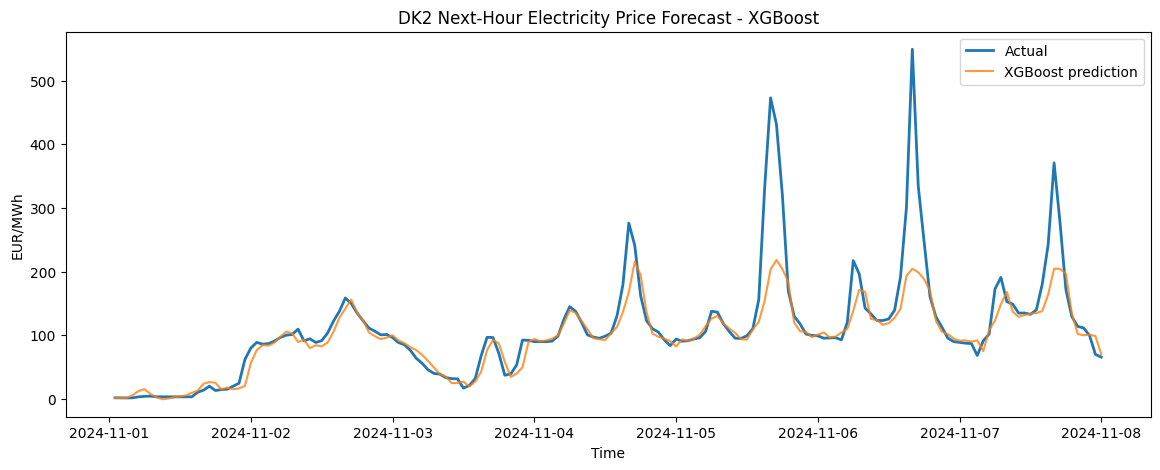

In [30]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_next_hour"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_xgboost"],
    label="XGBoost prediction",
    alpha=0.8
)

plt.title("DK2 Next-Hour Electricity Price Forecast - XGBoost")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [31]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
5,SpotPriceEUR,0.284085
26,renewable_generation_mwh,0.177958
19,CentralPowerMWh,0.080715
24,solar_mwh,0.052933
9,price_rolling_mean_24h,0.046082
31,PowerToHeatMWh,0.041046
4,is_weekend,0.034256
27,net_load_mwh,0.031471
17,shortwave_radiation,0.031101
20,LocalPowerMWh,0.028688


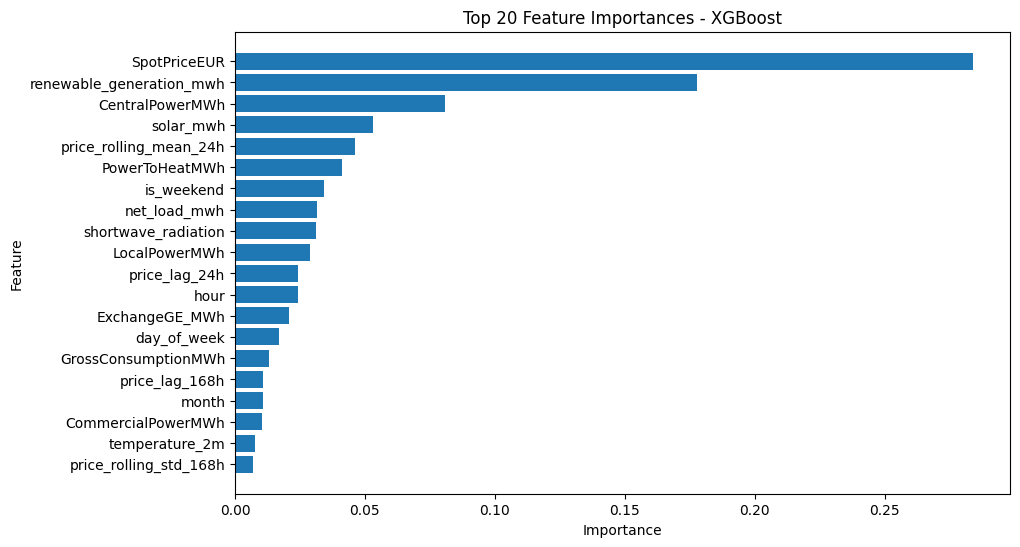

In [32]:
top_importance = importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclusion

The XGBoost model achieved a MAE of 14.12 EUR/MWh and RMSE of 39.48 EUR/MWh.  
The strongest baseline remains the current price baseline with a MAE of 12.31 EUR/MWh.

This suggests that for next-hour electricity price forecasting, short-term price persistence is very strong.  
The model still provides useful insight through feature importance, showing that current price, renewable generation, central power production, solar generation and net load are relevant explanatory variables.

A natural next step is to test longer forecast horizons, such as 24-hour-ahead forecasting, where weather and energy fundamentals may add more value than in the next-hour setting.

In [33]:
print("Best model by MAE:")
display(comparison.iloc[0])

print("XGBoost vs Current Price Baseline:")
baseline_mae = comparison.loc[comparison["model"] == "Current price baseline", "MAE"].values[0]
xgb_mae = comparison.loc[comparison["model"] == "XGBoost", "MAE"].values[0]

improvement = (baseline_mae - xgb_mae) / baseline_mae * 100
print(f"Improvement vs baseline: {improvement:.2f}%")

Best model by MAE:


model    Current price baseline
MAE                       12.31
RMSE                      24.48
Name: 0, dtype: object

XGBoost vs Current Price Baseline:
Improvement vs baseline: -14.70%
